# Visualise all the locations

In [5]:
import pickle

import os
import json
import pickle

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from networks import PrimalNetEndToEnd  # make sure this is importable
# from gep_config_parser import parse_config  # only if you really need it

from gep_config_parser import parse_config

In [6]:
CONFIG_FILE_NAME = "config.toml"
data_path = f"experiment-output/ch5/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_smp15.pkl"
data = pickle.load(open(data_path, 'rb'))

input_data = parse_config(CONFIG_FILE_NAME) # Reads the input data using config.toml's experiment.inputs.data path.

gep_ed_data = input_data["experiment"]["experiments"][0]

In [9]:
print(gep_ed_data.keys())

dict_keys(['representative_period_weight', 'value_of_lost_load', 'ramping_value', 'demand_data', 'generation_data', 'generation_availability_data', 'transmission_lines_data', 'times', 'nodes', 'generators', 'transmission_lines', 'crossover', 'rounding', 'output_file', 'output_log', 'ramping', 'relaxed'])


In [12]:
print(f"All the locations:")
print(gep_ed_data["nodes"])
print(f"Lines between locations:")
print(gep_ed_data["transmission_lines"])

All the locations:
['AUS', 'BEL', 'BLK', 'BLT', 'CZE', 'DEN', 'FIN', 'FRA', 'GER', 'IRE', 'ITA', 'NED', 'NOR', 'POL', 'POR', 'SKO', 'SPA', 'SWE', 'SWI', 'UKI']
Lines between locations:
[('AUS', 'BLK'), ('AUS', 'CZE'), ('AUS', 'GER'), ('AUS', 'ITA'), ('AUS', 'SWI'), ('BEL', 'FRA'), ('BEL', 'GER'), ('BEL', 'NED'), ('BEL', 'UKI'), ('BLK', 'ITA'), ('BLK', 'SKO'), ('BLT', 'FIN'), ('BLT', 'POL'), ('BLT', 'SWE'), ('CZE', 'GER'), ('CZE', 'SKO'), ('DEN', 'NED'), ('DEN', 'NOR'), ('DEN', 'SWE'), ('DEN', 'UKI'), ('FIN', 'SWE'), ('FRA', 'IRE'), ('FRA', 'ITA'), ('FRA', 'UKI'), ('GER', 'DEN'), ('GER', 'FRA'), ('GER', 'NED'), ('GER', 'NOR'), ('GER', 'SWE'), ('GER', 'UKI'), ('NED', 'NOR'), ('NED', 'UKI'), ('NOR', 'UKI'), ('POL', 'CZE'), ('POL', 'GER'), ('POL', 'SKO'), ('POL', 'SWE'), ('SPA', 'FRA'), ('SPA', 'POR'), ('SWE', 'NOR'), ('SWI', 'FRA'), ('SWI', 'GER'), ('SWI', 'ITA'), ('UKI', 'IRE')]


In [ ]:
print(gep_ed_data["genenodesrators"]) 
# Get the one with (NED,*)
# Filter the list for tuples starting with 'NED'


[('AUS', 'Gas'), ('AUS', 'Oil'), ('AUS', 'SunPV'), ('AUS', 'WindOff'), ('AUS', 'WindOn'), ('BEL', 'Gas'), ('BEL', 'Oil'), ('BEL', 'SunPV'), ('BEL', 'WindOff'), ('BEL', 'WindOn'), ('BLK', 'Coal'), ('BLK', 'Gas'), ('BLK', 'Lignite'), ('BLK', 'Nuclear'), ('BLK', 'Oil'), ('BLK', 'SunPV'), ('BLK', 'WindOff'), ('BLK', 'WindOn'), ('BLT', 'Gas'), ('BLT', 'Oil'), ('BLT', 'SunPV'), ('BLT', 'WindOff'), ('BLT', 'WindOn'), ('CZE', 'Coal'), ('CZE', 'Gas'), ('CZE', 'Lignite'), ('CZE', 'Nuclear'), ('CZE', 'SunPV'), ('CZE', 'WindOff'), ('CZE', 'WindOn'), ('DEN', 'Gas'), ('DEN', 'Oil'), ('DEN', 'SunPV'), ('DEN', 'WindOff'), ('DEN', 'WindOn'), ('FIN', 'Gas'), ('FIN', 'Nuclear'), ('FIN', 'SunPV'), ('FIN', 'WindOff'), ('FIN', 'WindOn'), ('FRA', 'Gas'), ('FRA', 'Nuclear'), ('FRA', 'Oil'), ('FRA', 'SunPV'), ('FRA', 'WindOff'), ('FRA', 'WindOn'), ('GER', 'Coal'), ('GER', 'Gas'), ('GER', 'Lignite'), ('GER', 'Oil'), ('GER', 'SunPV'), ('GER', 'WindOff'), ('GER', 'WindOn'), ('IRE', 'Coal'), ('IRE', 'Gas'), ('IRE'

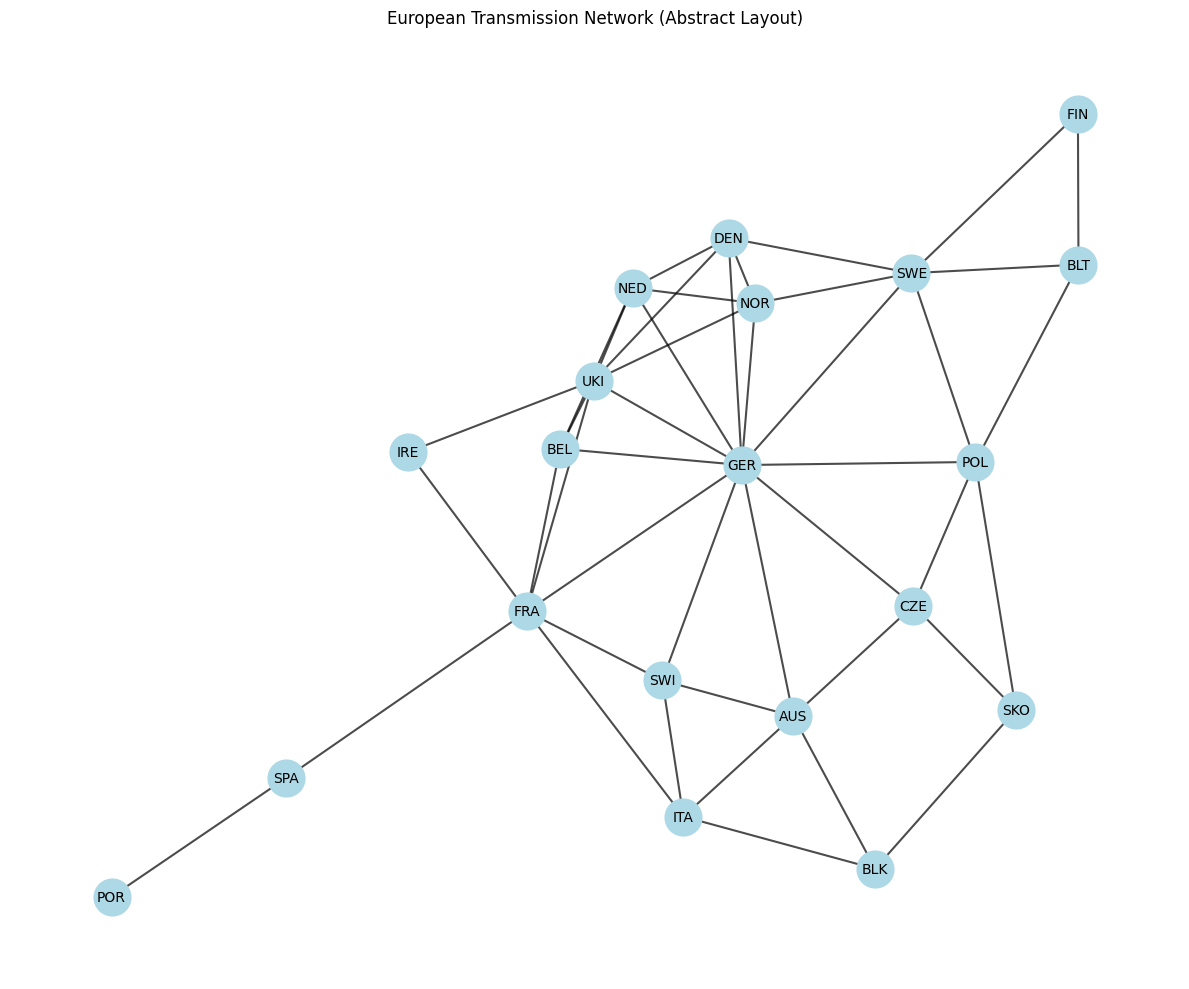

In [13]:
import networkx as nx
import matplotlib.pyplot as plt

# Your data
nodes = gep_ed_data["nodes"]
edges = gep_ed_data["transmission_lines"]

# Build graph
G = nx.Graph()
G.add_nodes_from(nodes)
G.add_edges_from(edges)

# Layout
pos = nx.spring_layout(G, seed=42)  # reproducible

# Plot
plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(G, pos, node_size=700, node_color="lightblue")
nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.7)
nx.draw_networkx_labels(G, pos, font_size=10)

plt.title("European Transmission Network (Abstract Layout)")
plt.axis("off")
plt.tight_layout()
plt.show()


In [41]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_subgraph(
    nodes,
    edges,
    selected_nodes,
    layout_seed=42,
    figsize=(6, 4),
    node_size=800,
    node_color="lightblue",
    edge_width=2.0,
):
    """
    Plot only selected nodes and edges between them.

    nodes: list of all nodes
    edges: list of (u, v) edges
    selected_nodes: list or set of nodes to plot
    """

    # Build full graph
    G = nx.Graph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)

    # Induced subgraph
    SG = G.subgraph(selected_nodes).copy()

    # Layout on subgraph only
    pos = nx.spring_layout(SG, seed=layout_seed)

    # Plot
    plt.figure(figsize=figsize)
    nx.draw_networkx_nodes(SG, pos, node_size=node_size, node_color=node_color)
    nx.draw_networkx_edges(SG, pos, width=edge_width)
    nx.draw_networkx_labels(SG, pos, font_size=10)

    plt.title(f"Subgraph ({len(SG.nodes)} nodes)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


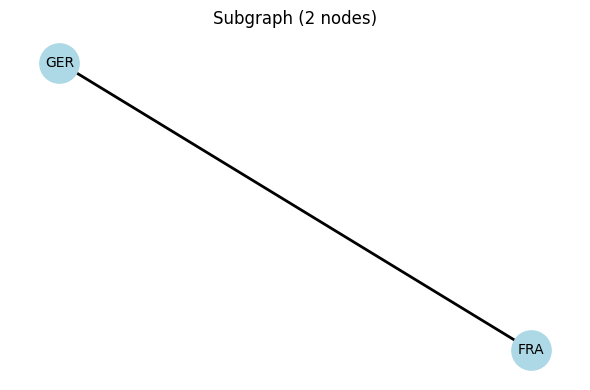

In [43]:
selected = ["GER", "FRA", "NED", "AUS"]
plot_subgraph(nodes, edges, selected)



## Select a 4th country

To join original experiment with:
- BEL
- GER
- FRA

In [46]:
swiss_generators = [gen for gen in gep_ed_data["generators"] if gen[0] == 'SPA']
print("Generators in SPA:")
print(swiss_generators)
print(f"Lines with ITSPAA:")
swiss_lines = [line for line in gep_ed_data["transmission_lines"] if 'SPA' in line]
print(swiss_lines)

Generators in SPA:
[('SPA', 'Gas'), ('SPA', 'Nuclear'), ('SPA', 'SunPV'), ('SPA', 'WindOff'), ('SPA', 'WindOn')]
Lines with ITSPAA:
[('SPA', 'FRA'), ('SPA', 'POR')]


In [32]:
data_4Node_path = "data/ED_data/ED_NB-G-F-S_GB2-G2-F2-S2_L5_c0_s0_p0_smp15.pkl"
data_4Node = pickle.load(open(data_4Node_path, 'rb'))
print(data_4Node.N)
print(data_4Node.L)

['BEL', 'GER', 'FRA', 'SWI']
[('BEL', 'GER'), ('BEL', 'FRA'), ('GER', 'FRA'), ('SWI', 'FRA'), ('SWI', 'GER')]


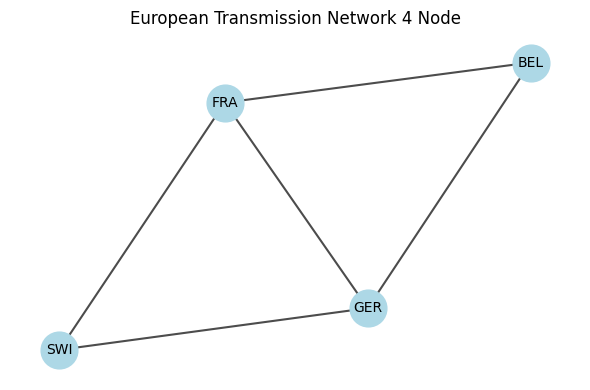

In [35]:
# Build graph
nodes = data_4Node.N
edges = data_4Node.L
G = nx.Graph()
G.add_nodes_from(nodes)
G.add_edges_from(edges)

# Layout
pos = nx.spring_layout(G, seed=42)  # reproducible

# Plot
plt.figure(figsize=(6, 4))
nx.draw_networkx_nodes(G, pos, node_size=700, node_color="lightblue")
nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.7)
nx.draw_networkx_labels(G, pos, font_size=10)

plt.title("European Transmission Network 4 Node")
plt.axis("off")
plt.tight_layout()
plt.show()